**Name:** Sarah Ali
**Roll No.:** 2023BTCSE014
**Program:** B.Tech. (CSE)
**Course:** Soft Computing (EL1)
**Course Code:** STDA2102
**Assignment 2 - Module 2 (Practical Exercise: Neural Networks)**

### Question 1:
To understand and implement the basic working of an artificial neuron using Python.

In [1]:
import numpy as np

def artificial_neuron(inputs, weights, bias, activation="step"):
    weighted_sum = np.dot(inputs, weights) + bias
    if activation == "step":
        output = 1 if weighted_sum >= 0 else 0
    elif activation == "sigmoid":
        output = 1 / (1 + np.exp(-weighted_sum))
    return weighted_sum, output

print("Artificial neuron function ready")

Artificial neuron function ready


In [2]:
# Single neuron forward pass
inputs = np.array([0.5, 0.8, -0.2])
weights = np.array([0.4, 0.3, 0.6])
bias = -0.1

z, out_step = artificial_neuron(inputs, weights, bias, activation="step")
_, out_sigmoid = artificial_neuron(inputs, weights, bias, activation="sigmoid")

print(f"Inputs           : {inputs}")
print(f"Weights          : {weights}")
print(f"Bias             : {bias}")
print(f"Weighted Sum (z) : {z:.4f}")
print(f"Output (Step)    : {out_step}")
print(f"Output (Sigmoid) : {out_sigmoid:.4f}")

Inputs           : [ 0.5  0.8 -0.2]
Weights          : [0.4 0.3 0.6]
Bias             : -0.1
Weighted Sum (z) : 0.2200
Output (Step)    : 1
Output (Sigmoid) : 0.5548


In [3]:
# Test neuron on multiple input vectors
test_cases = [
    np.array([0.1, 0.2, 0.3]),
    np.array([0.9, 0.9, 0.9]),
    np.array([-0.5, 0.4, 0.1]),
]
test_weights = np.array([0.4, 0.3, 0.6])

for i, x in enumerate(test_cases, start=1):
    z, out = artificial_neuron(x, test_weights, bias, activation="step")
    print(f"Case {i}: x={x}, z={round(z,4)}, out={out}")

Case 1: x=[0.1 0.2 0.3], z=0.18, out=1
Case 2: x=[0.9 0.9 0.9], z=1.07, out=1
Case 3: x=[-0.5  0.4  0.1], z=-0.12, out=0


### Question 2:
To implement the weighted sum of inputs and bias used in an artificial neuron using Python.

In [4]:
import numpy as np

def weighted_sum(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

print("Weighted sum function ready")

Weighted sum function ready


In [5]:
# Verify manual arithmetic against vector dot product
x = np.array([1.0, 0.5, 0.2])
w = np.array([0.6, -0.4, 0.3])
b = 0.2

manual_z = (x[0]*w[0] + x[1]*w[1] + x[2]*w[2]) + b
z = weighted_sum(x, w, b)

print(f"Manual: {manual_z:.4f} | Function: {z:.4f} | Matched: {manual_z == z}")

Manual: 0.6600 | Function: 0.6600 | Matched: True


In [6]:
# Compute weighted sum for a batch of inputs
input_sets = np.array([
    [1.0, 0.5, 0.2],
    [0.3, 0.9, 0.4],
    [0.7, 0.1, 0.6],
])
weights = np.array([0.6, -0.4, 0.3])
bias = 0.2

for i, row in enumerate(input_sets, start=1):
    z = weighted_sum(row, weights, bias)
    print(f"Sample {i}: Input={row}, z={round(z, 4)}")

Sample 1: Input=[1.  0.5 0.2], z=0.66
Sample 2: Input=[0.3 0.9 0.4], z=0.14
Sample 3: Input=[0.7 0.1 0.6], z=0.76


### Question 3:
To implement and visualize Sigmoid, Tanh, and ReLU activation functions using Python.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)

print("Activation functions ready")

Activation functions ready


In [8]:
# Evaluate activations at sample points
for val in [-2, 0, 2]:
    print(f"x={val:>2} -> sigmoid: {sigmoid(val):.3f}, tanh: {tanh(val):.3f}, relu: {relu(val):.3f}")

x=-2 -> sigmoid: 0.119, tanh: -0.964, relu: 0.000
x= 0 -> sigmoid: 0.500, tanh: 0.000, relu: 0.000
x= 2 -> sigmoid: 0.881, tanh: 0.964, relu: 2.000


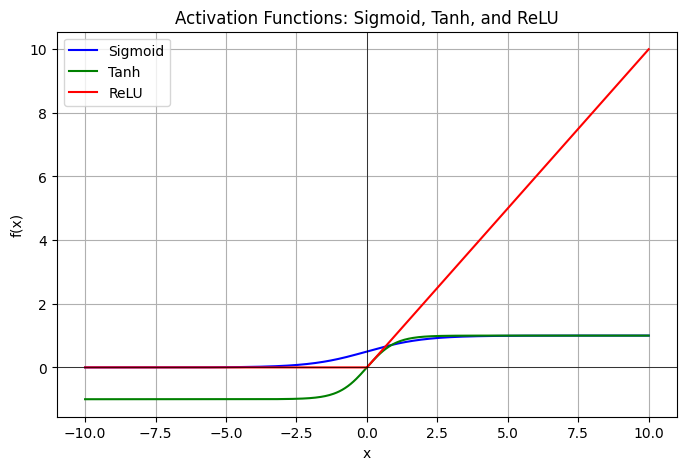

Activation functions plotted successfully


In [9]:
# Plot the activation curves
x = np.linspace(-10, 10, 400)

plt.figure(figsize=(8, 5))
plt.plot(x, sigmoid(x), label="Sigmoid", color="blue")
plt.plot(x, tanh(x), label="Tanh", color="green")
plt.plot(x, relu(x), label="ReLU", color="red")
plt.title("Activation Functions: Sigmoid, Tanh, and ReLU")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()
print("Activation functions plotted successfully")

### Question 4:
To create a simple single-layer neural network using Python.

In [10]:
import numpy as np

class SingleLayerNN:
    def __init__(self, n_inputs, learning_rate=0.1):
        self.weights = np.zeros(n_inputs)
        self.bias = 0.0
        self.lr = learning_rate

    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return 1 if z >= 0 else 0

    def train(self, X, y, epochs=10):
        for epoch in range(epochs):
            total_error = 0
            for xi, target in zip(X, y):
                error = target - self.predict(xi)
                self.weights += self.lr * error * xi
                self.bias += self.lr * error
                total_error += abs(error)
            print(f"Epoch {epoch+1}: Weights={self.weights}, Bias={self.bias:.2f}, Errors={total_error}")

print("SingleLayerNN class ready")

SingleLayerNN class ready


In [11]:
# Train on the logical AND function
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

model = SingleLayerNN(n_inputs=2, learning_rate=0.1)
model.train(X, y, epochs=10)

Epoch 1: Weights=[0.1 0.1], Bias=0.00, Errors=2
Epoch 2: Weights=[0.2 0.1], Bias=-0.10, Errors=3
Epoch 3: Weights=[0.2 0.1], Bias=-0.20, Errors=3
Epoch 4: Weights=[0.2 0.1], Bias=-0.20, Errors=0
Epoch 5: Weights=[0.2 0.1], Bias=-0.20, Errors=0
Epoch 6: Weights=[0.2 0.1], Bias=-0.20, Errors=0
Epoch 7: Weights=[0.2 0.1], Bias=-0.20, Errors=0
Epoch 8: Weights=[0.2 0.1], Bias=-0.20, Errors=0
Epoch 9: Weights=[0.2 0.1], Bias=-0.20, Errors=0
Epoch 10: Weights=[0.2 0.1], Bias=-0.20, Errors=0


In [12]:
# Test the trained network
print("Final predictions:")
for xi in X:
    print(f"Input: {xi} -> Predicted Output: {model.predict(xi)}")

Final predictions:
Input: [0 0] -> Predicted Output: 0
Input: [0 1] -> Predicted Output: 0
Input: [1 0] -> Predicted Output: 0
Input: [1 1] -> Predicted Output: 1


### Question 5:
To create a Multilayer Perceptron (MLP) with input, hidden, and output layers using Keras/TensorFlow.

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# XOR dataset (not linearly separable, needs a hidden layer)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([0, 1, 1, 0], dtype=np.float32)

print("XOR dataset ready")

I0000 00:00:1788719786.668852     502 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788719786.670832     502 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788719800.425941     502 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788719807.868125     502 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788719807.869992     502 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


XOR dataset ready


In [14]:
# Build the MLP: 2 input nodes -> 8 hidden nodes -> 1 output node
tf.random.set_seed(7)

model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(8, activation="relu", name="hidden_layer"),
    layers.Dense(1, activation="sigmoid", name="output_layer"),
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05),
              loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

E0000 00:00:1788719810.761126     502 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train and test on XOR
history = model.fit(X, y, epochs=1000, verbose=0)

print(f"Final training accuracy: {history.history['accuracy'][-1]:.2f}")
print(f"Final training loss    : {history.history['loss'][-1]:.4f}")

preds = (model.predict(X, verbose=0) > 0.5).astype(int).flatten()
print(f"Targets: {y.astype(int).tolist()}")
print(f"Preds  : {preds.tolist()}")
print("XOR solved successfully")

Final training accuracy: 1.00
Final training loss    : 0.0002
Targets: [0, 1, 1, 0]
Preds  : [0, 1, 1, 0]
XOR solved successfully


### Question 6:
To apply Gradient Descent for updating the weights of a simple neural network during training.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Simple dataset: y = 2x + 1 (with a bit of noise)
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3.1, 4.9, 7.2, 8.9, 11.1], dtype=float)

w, b = 0.0, 0.0
learning_rate = 0.01
epochs = 1000
n = len(X)
loss_history = []

print("Setup ready")

Setup ready


In [17]:
# Train using Gradient Descent
for epoch in range(epochs):
    y_pred = w * X + b
    error = y_pred - y
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    dw = (2 / n) * np.dot(error, X)
    db = (2 / n) * np.sum(error)
    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | w: {w:.4f} | b: {b:.4f}")

print(f"\nFinal parameters -> w: {w:.4f}, b: {b:.4f}")

Epoch    0 | Loss: 57.5760 | w: 0.5024 | b: 0.1408
Epoch  100 | Loss: 0.0332 | w: 2.0888 | b: 0.7194
Epoch  200 | Loss: 0.0240 | w: 2.0633 | b: 0.8115
Epoch  300 | Loss: 0.0193 | w: 2.0451 | b: 0.8771
Epoch  400 | Loss: 0.0169 | w: 2.0322 | b: 0.9239
Epoch  500 | Loss: 0.0157 | w: 2.0229 | b: 0.9573
Epoch  600 | Loss: 0.0150 | w: 2.0163 | b: 0.9810
Epoch  700 | Loss: 0.0147 | w: 2.0116 | b: 0.9980
Epoch  800 | Loss: 0.0146 | w: 2.0083 | b: 1.0100
Epoch  900 | Loss: 0.0145 | w: 2.0059 | b: 1.0187

Final parameters -> w: 2.0042, b: 1.0247


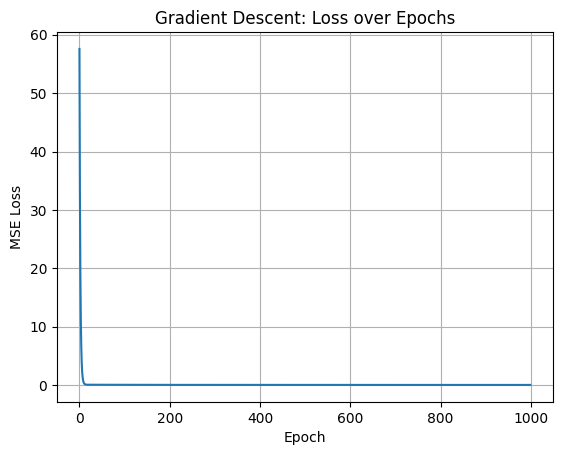

Loss minimized successfully


In [18]:
# Plot the loss curve
plt.plot(loss_history)
plt.title("Gradient Descent: Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()
print("Loss minimized successfully")

### Question 7:
To understand and implement the basic concept of Backpropagation for training a neural network.

In [19]:
import numpy as np

def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x): return x * (1 - x)

print("Functions ready")

Functions ready


In [20]:
# XOR dataset and 2-2-1 network initialization
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

np.random.seed(42)
W1 = np.random.uniform(size=(2, 2))
b1 = np.random.uniform(size=(1, 2))
W2 = np.random.uniform(size=(2, 1))
b2 = np.random.uniform(size=(1, 1))

learning_rate = 0.5
print("Network initialized")

Network initialized


In [21]:
# Train using forward + backward propagation
for epoch in range(10000):
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)
    final_input = np.dot(hidden_output, W2) + b2
    final_output = sigmoid(final_input)

    error = y - final_output
    d_output = error * sigmoid_derivative(final_output)
    error_hidden = d_output.dot(W2.T)
    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    if epoch % 2000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {np.mean(np.square(error)):.4f}")

Epoch     0 | Loss: 0.3247
Epoch  2000 | Loss: 0.0025


Epoch  4000 | Loss: 0.0009
Epoch  6000 | Loss: 0.0005


Epoch  8000 | Loss: 0.0004


In [22]:
# Final predictions after training
print("Final predictions after training:")
for xi, target in zip(X, y):
    hidden_output = sigmoid(np.dot(xi, W1) + b1)
    output = sigmoid(np.dot(hidden_output, W2) + b2)
    print(f"Input: {xi} -> Predicted: {output[0][0]:.4f} -> Expected: {target[0]}")

Final predictions after training:
Input: [0 0] -> Predicted: 0.0189 -> Expected: 0
Input: [0 1] -> Predicted: 0.9837 -> Expected: 1
Input: [1 0] -> Predicted: 0.9837 -> Expected: 1
Input: [1 1] -> Predicted: 0.0169 -> Expected: 0


### Question 8:
To train a simple neural network model on a dataset using Keras/TensorFlow.

In [23]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]} samples")

Train: 120, Test: 30 samples


In [24]:
# Build and train the model
model_iris = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax"),
])
model_iris.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model_iris.fit(X_train, y_train, epochs=150, validation_split=0.2, verbose=0)

print(f"Final training accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy : {history.history['val_accuracy'][-1]:.4f}")
print("Model trained successfully")

Final training accuracy   : 0.9062
Final validation accuracy : 0.9167
Model trained successfully


### Question 9:
To evaluate the performance of a trained neural network using suitable evaluation metrics in Python.

In [25]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred_probs = model_iris.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred)}")

Accuracy  : 0.8000
Precision : 0.8254
Recall    : 0.8000
F1-Score  : 0.7917
Confusion matrix:
[[10  0  0]
 [ 0  5  5]
 [ 0  1  9]]


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=data.target_names))
print("Evaluation complete")

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      0.50      0.62        10
   virginica       0.64      0.90      0.75        10

    accuracy                           0.80        30
   macro avg       0.83      0.80      0.79        30
weighted avg       0.83      0.80      0.79        30

Evaluation complete


### Question 10:
To design, train, and evaluate a complete Artificial Neural Network-based classification system using Python and Keras/TensorFlow.

In [27]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data_bc = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data_bc.data, data_bc.target, test_size=0.2, random_state=42, stratify=data_bc.target)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]} samples, Features: {X_train.shape[1]}")

Train: 455, Test: 114 samples, Features: 30


In [28]:
# Build and train the complete ANN classifier
model_bc = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu", name="hidden_layer_1"),
    layers.Dense(8, activation="relu", name="hidden_layer_2"),
    layers.Dense(1, activation="sigmoid", name="output_layer"),
])
model_bc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_bc.summary()

history = model_bc.fit(X_train, y_train, epochs=150, validation_split=0.2, verbose=0)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Evaluate the trained system
from sklearn.metrics import confusion_matrix, classification_report

test_loss, test_accuracy = model_bc.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

y_pred = (model_bc.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=data_bc.target_names)}")

Test Loss     : 0.1370
Test Accuracy : 0.9649

Confusion Matrix:
[[41  1]
 [ 3 69]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



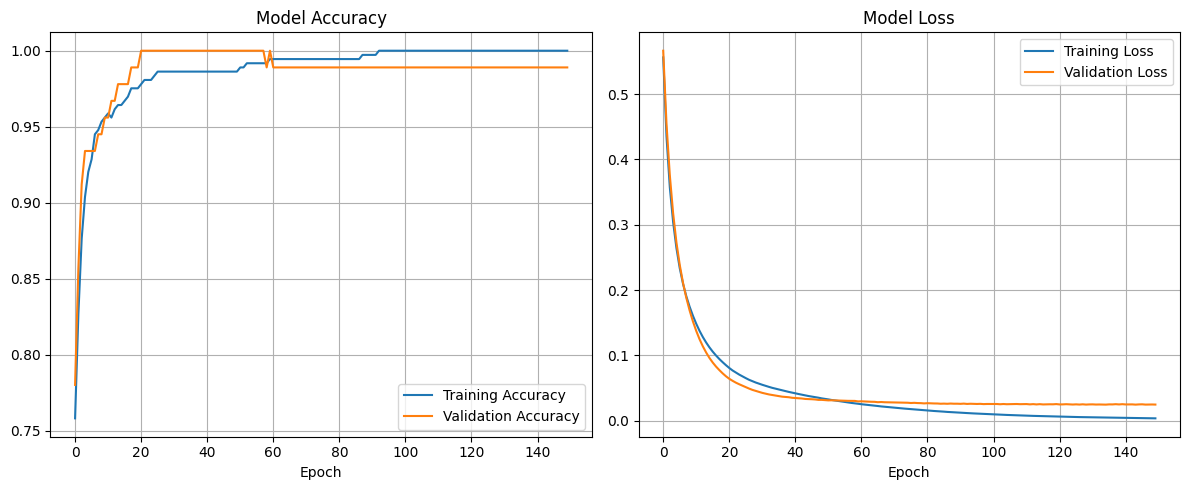

System completed successfully


In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history.history["accuracy"], label="Training Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Model Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history["loss"], label="Training Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Model Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()
print("System completed successfully")